# Finalize `price_dislocation` for the model

`price_dislocation` **cleared screening** ([`01_screening.ipynb`](01_screening.ipynb)) — it is computed
correctly and carries real signal for both heads. This is **step 2 — finalize it for the model**: pick the
time-scale per head, shape the feature for the network, decide single-vs-per-exchange, and run the ship checklist.

Wiring only — the engines are shared, tested code: span/head selection (`boba.research.selection`), input
shaping (`boba.research.shaping`). The **method** is in [`METHOD.md`](METHOD.md).

We evaluate on an **event-gated grid** (`build_context(grid_ms=1, active_only=True, hours=2)`): a regular
1 ms grid, keeping only the ms windows that carried an event (book update or trade) from *any* exchange,
over the first 2 h of the block. A uniform 50 ms wall-clock grid catches a ~ms-lived, event-coincident
feature state only ~10% of the time; a 1 ms active grid samples it while skipping dead time (no examples
where nothing happened). `grid_ms` sets the resolution (raise it — e.g. 5 — if compute is heavy) and
`hours` caps how much of the block is read.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
from boba.features import base
import boba.features.price_dislocation                      # registers the feature
from boba.research.screening import build_context, build_family, best_span
from boba.research.selection import fixed_move_targets, ic_grid, per_exchange_vs_single
from boba.research.shaping import shaping_report

ctx  = build_context(grid_ms=1, active_only=True, hours=2)   # 1 ms grid, keep only ms windows with an event (any venue); first 2 h
spec = base.get("price_dislocation")
GRID = [(nf, ns) for nf in (1, 10, 50, 200, 500, 1000)
                 for ns in (100, 500, 1000, 2000, 5000, 10000) if nf < ns]
FAST = sorted({nf for nf, ns in GRID}); SLOW = sorted({ns for nf, ns in GRID})
family = build_family(ctx, spec.vectorized, GRID, n_jobs=18)                  # {(nf,ns): {source: vector}}
print(f"block {ctx.block}   {len(GRID)} spans   sources {ctx.sources}")
print(f"{len(ctx.anchor_ts):,} examples (anchors) on the event-gated grid   from {len(ctx.merged_ts):,} trade ticks")

def show_grids(grids, title):                                                # the only viz helper (§7 plotter)
    fig, axes = plt.subplots(1, len(grids), figsize=(5.4 * len(grids), 4.0), squeeze=False)
    for ax, (src, g) in zip(axes[0], grids.items()):
        im = ax.imshow(g, cmap="viridis", aspect="auto")
        ax.set_xticks(range(len(SLOW))); ax.set_xticklabels(SLOW); ax.set_xlabel("slow span")
        ax.set_yticks(range(len(FAST))); ax.set_yticklabels(FAST); ax.set_ylabel("fast span")
        ax.set_title(f"{title} — {src}")
        for i in range(len(FAST)):
            for j in range(len(SLOW)):
                if np.isfinite(g[i, j]):
                    ax.text(j, i, f"{g[i, j]:.3f}", ha="center", va="center", color="w", fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046)
    fig.tight_layout(); plt.show()

block holocron.20260520T135822.0   30 spans   sources ('bin', 'okx')
1,306,767 examples (anchors) on the event-gated grid   from 304,617 trade ticks


## 1. Which time-scale per head? — the IC breakdown

Where the signal lives across the fast/slow span family, per source — the same sweep as the monolith
template's §7 (minus its conditional 2nd-span re-score):
- **price head, count-conditioned (the `D_k` family)** — the signed feature vs the signed `n`-move
  return, and `|feature|` vs `|n-move return|`, for `n = 1, 3, 6, 9` (the `fixed_move_targets`);
- **rate head** — `|feature|` vs the move count.

The price grids score against a *range of fixed mid-move-count* targets — **not** the 100 ms wall-clock
return — isolating the per-move signal the price head learns. The signed price grids are **mirror-augmented**
(the tape reflected through byb's mid via the feature's own `spec.mirror`, here `np.negative`; the signed
target negates) so the IC is direction-free — see [`AUTHORING.md`](../../src/boba/features/AUTHORING.md)
→ Mirror augmentation. (Held-out span *selection* across blocks is the OOS harness; these in-sample grids
pick a representative scale.)

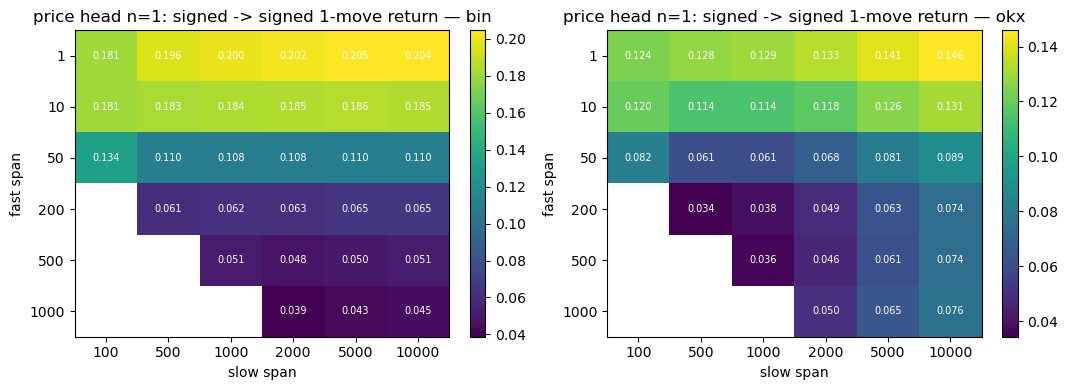

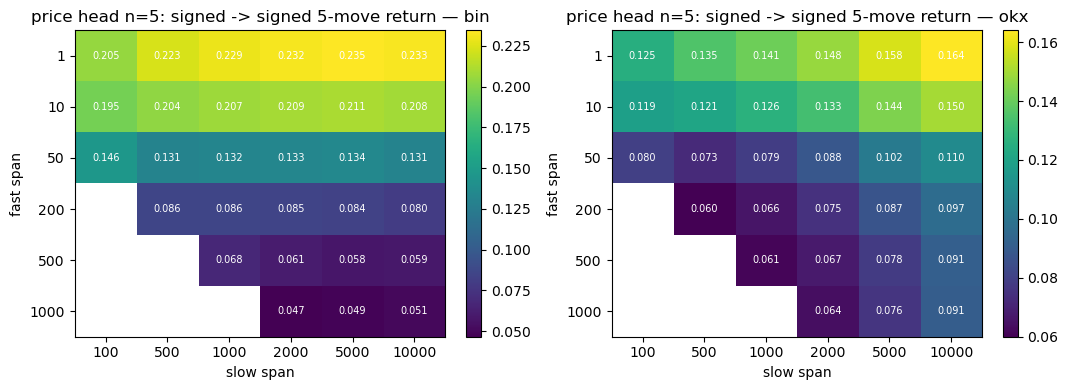

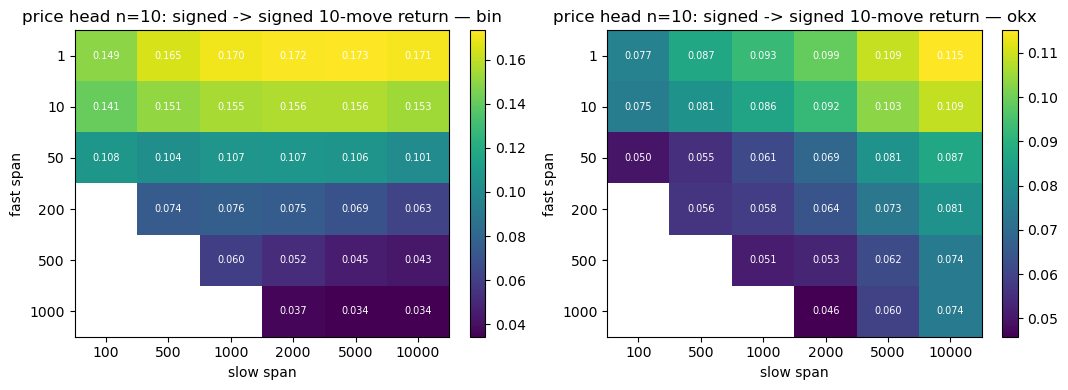

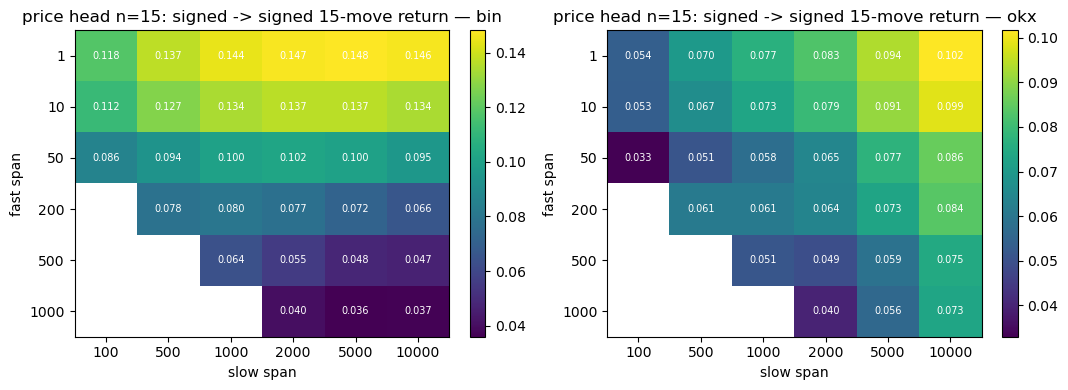

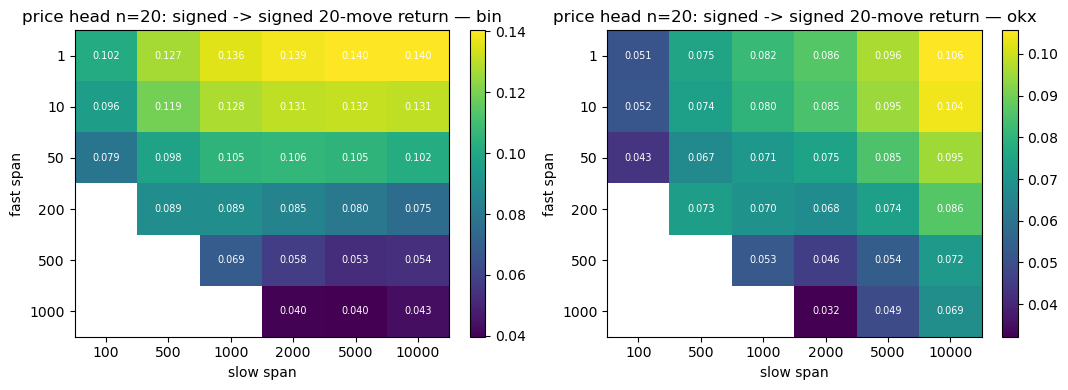

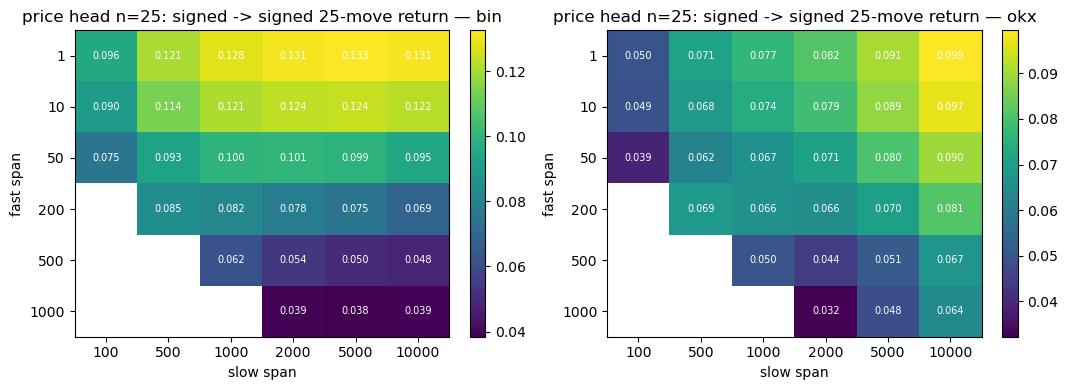

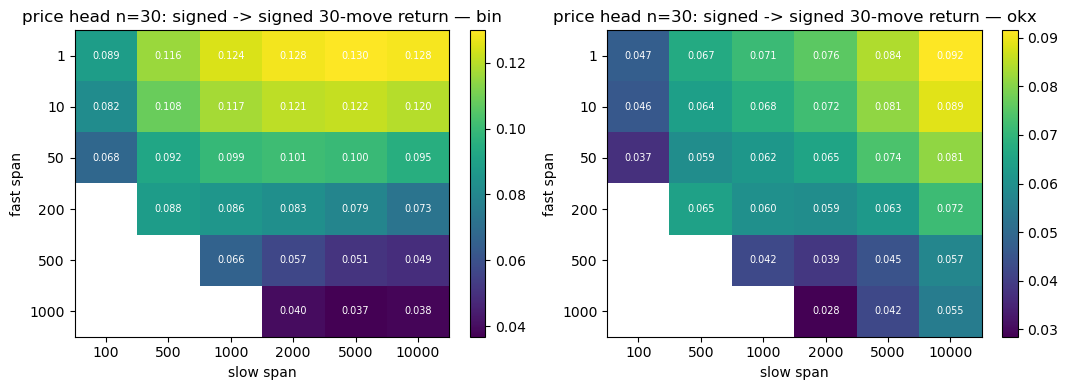

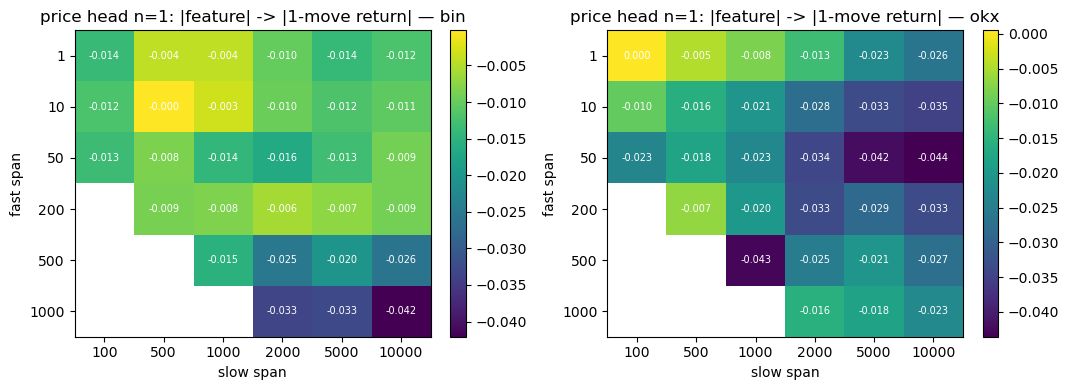

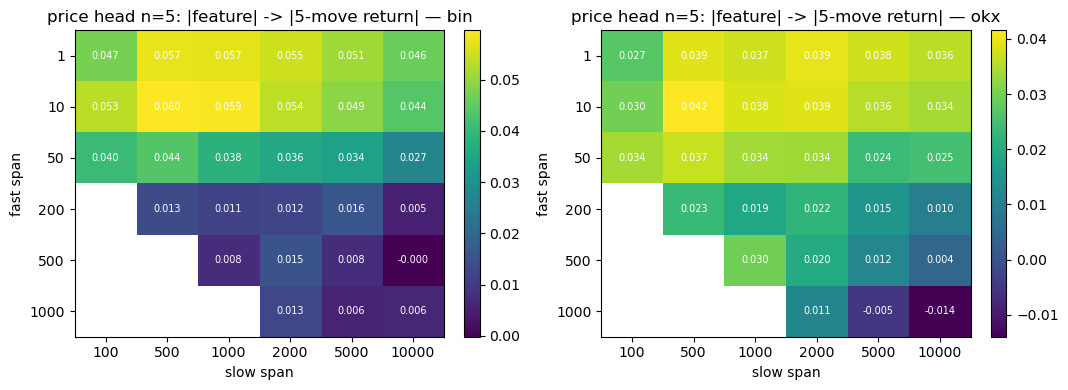

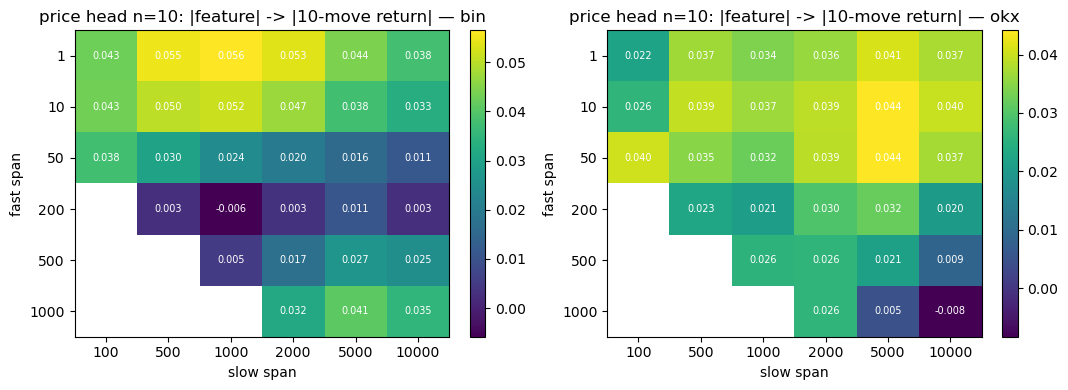

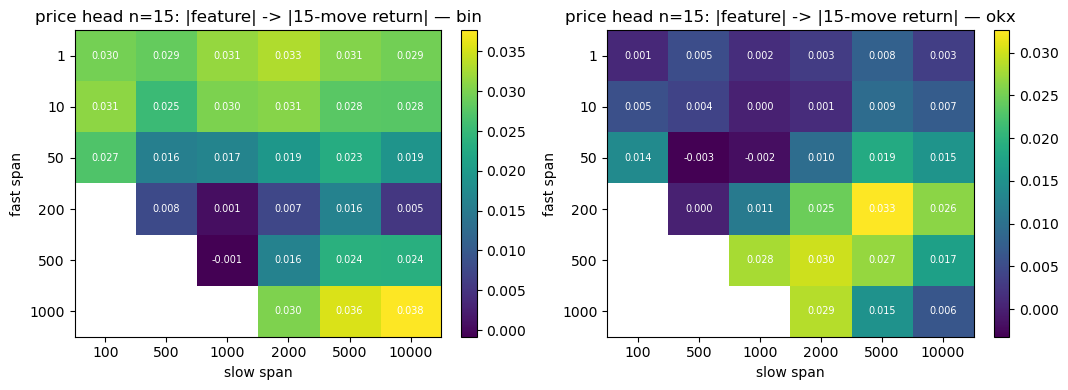

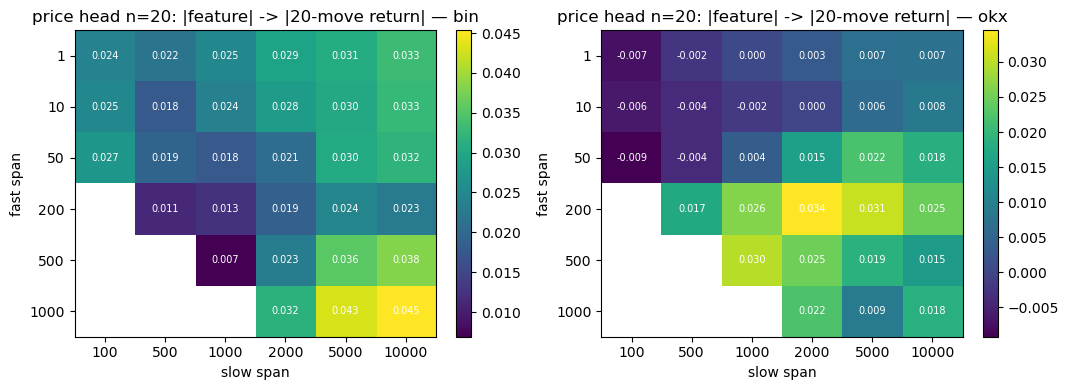

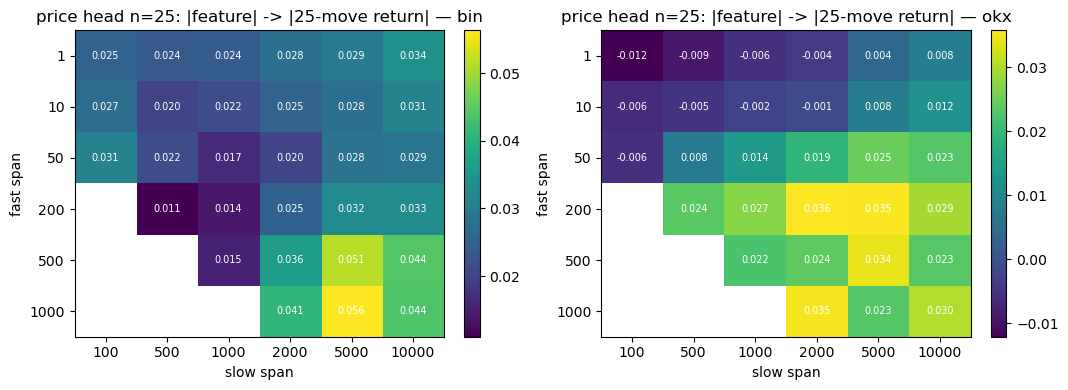

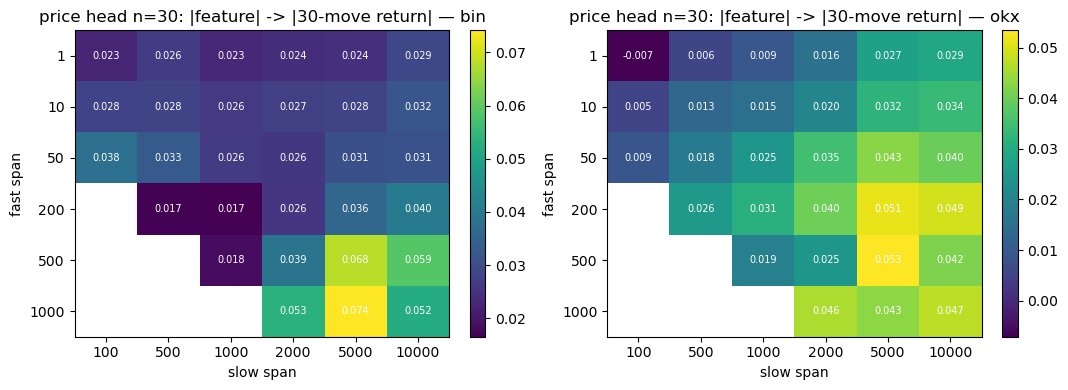

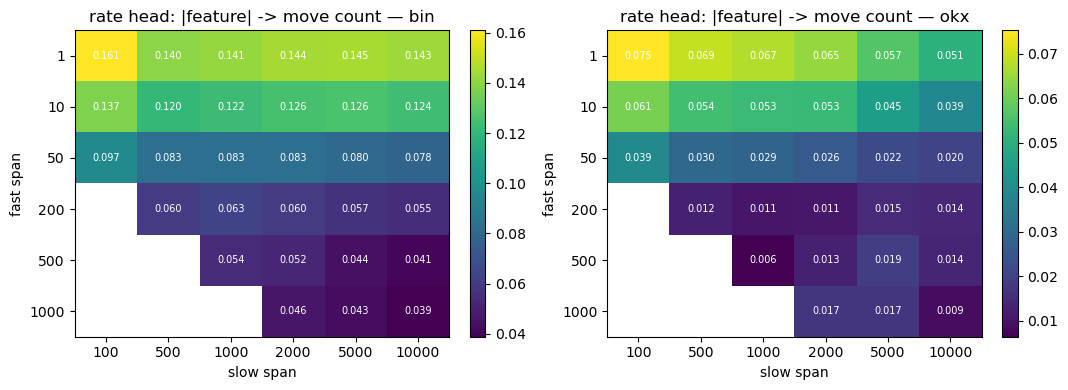

In [6]:
# the IC sweep — the monolith §7 grids (no conditional re-score; that is §2): count-conditioned price
# grids over the range of move-counts + the rate grid. No 100 ms target. fixed_move_targets / ic_grid
# are the shared, tested engines (boba.research.selection; ic_grid threads its scoring at n_jobs);
# show_grids is the §0 plotter above.
fmt = fixed_move_targets(ctx)                                                # {n: signed n-move return / σ_ev}, n = 1,3,6,9
signed = {n: ic_grid(ctx, family, t, n_jobs=18, mirror=spec.mirror)     for n, t in fmt.items()}   # signed feature -> signed n-move return (mirror-augmented)
magnit = {n: ic_grid(ctx, family, np.abs(t), magnitude=True, n_jobs=18) for n, t in fmt.items()}   # |feature| -> |n-move return| (sign-blind: no mirror)
rate_grid = ic_grid(ctx, family, ctx.rate_target, magnitude=True, n_jobs=18)                       # rate head: |feature| -> move count

for n in fmt:                                                                # all signed grids first ...
    show_grids(signed[n], f"price head n={n}: signed -> signed {n}-move return")
for n in fmt:                                                                # ... then all magnitude grids ...
    show_grids(magnit[n], f"price head n={n}: |feature| -> |{n}-move return|")
show_grids(rate_grid, "rate head: |feature| -> move count")                  # ... then the rate grid

In [7]:
# best (fast, slow) PER EXCHANGE per diagnostic — each source's OWN in-sample argmax (no exchange is
# privileged; a representative scale, not an OOS claim). One row per diagnostic; span + its rank-IC per source.
def _best_ex(grid, src):
    g = grid[src]; i, j = np.unravel_index(np.nanargmax(g), g.shape)
    return (FAST[i], SLOW[j]), float(g[i, j])
diagnostics = ([(f"price n={n} signed",    signed[n]) for n in fmt]
             + [(f"price n={n} |feature|", magnit[n]) for n in fmt]
             + [("rate |feature|->count",  rate_grid)])
rows = []
for name, grid in diagnostics:
    row = {"diagnostic": name}
    for s in ctx.sources:
        span, icv = _best_ex(grid, s)
        row[f"{s} span"] = str(span); row[f"{s} IC"] = round(icv, 3)
    rows.append(row)
pl.DataFrame(rows)

diagnostic,bin span,bin IC,okx span,okx IC
str,str,f64,str,f64
"""price n=1 signed""","""(1, 5000)""",0.205,"""(1, 10000)""",0.146
"""price n=5 signed""","""(1, 5000)""",0.235,"""(1, 10000)""",0.164
"""price n=10 signed""","""(1, 5000)""",0.173,"""(1, 10000)""",0.115
"""price n=15 signed""","""(1, 5000)""",0.148,"""(1, 10000)""",0.102
"""price n=20 signed""","""(1, 5000)""",0.14,"""(1, 10000)""",0.106
…,…,…,…,…
"""price n=15 |feature|""","""(1000, 10000)""",0.038,"""(200, 5000)""",0.033
"""price n=20 |feature|""","""(1000, 10000)""",0.045,"""(200, 2000)""",0.034
"""price n=25 |feature|""","""(1000, 5000)""",0.056,"""(200, 2000)""",0.036


In [8]:
# the in-sample span pick per head (feeds §2/§3 below): the (fast, slow) maximising mean rank-IC over the
# sources. Price head mirror-augmented (spec.mirror); rate head scores |feature| (sign-blind). A
# representative scale — held-out span selection across blocks is the OOS harness, not this notebook.
price_span = best_span(ctx, family, ctx.price_target, mirror=spec.mirror)
rate_span  = best_span(ctx, family, ctx.rate_target, score_magnitude=True)
print(f"price-head span {price_span}    rate-head span {rate_span}")

price-head span (1, 2000)    rate-head span (1, 100)


## 2. Input shaping for the network

Reshape the (already σ_ev-divided) feature for the network input — centred, unit-scale, no wild outliers —
with the **lightest** transform that clears the bar.

shaping report  (n=1,306,767, bar |·| <= 5)
  raw   std=1.74  skew=+0.66  excess_kurt=17.9  max|·|=45.9  (0 = normal)
  z-score        excess_kurt=   17.9   max|·|=  26.3
  robust+clip    excess_kurt=    1.1   max|·|=   4.0  <- recommended
  arcsinh        excess_kurt=   -0.5   max|·|=   4.1
  rank-Gaussian  excess_kurt=   -0.0   max|·|=   4.9
recommended transform: robust+clip


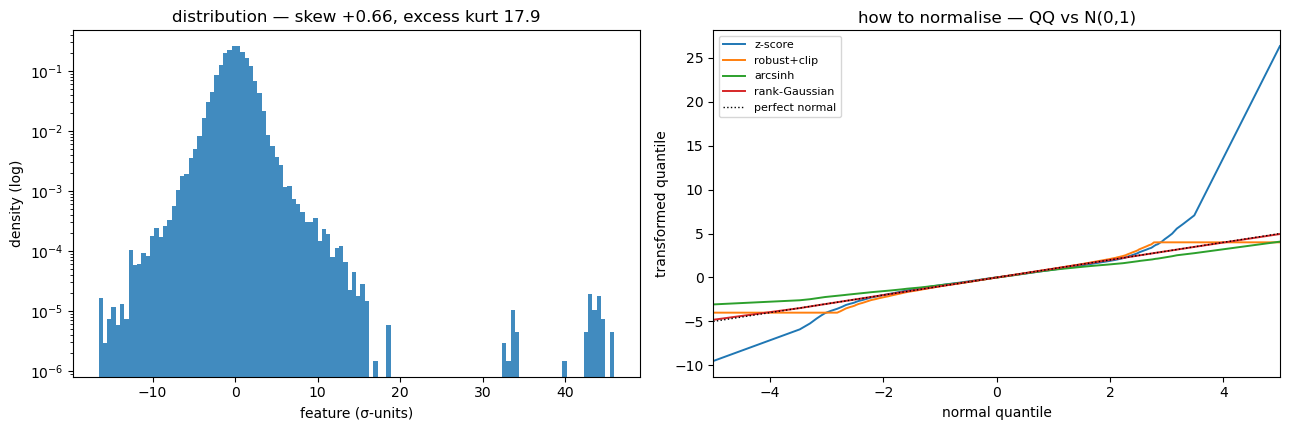

In [9]:
src = ctx.sources[0]                                                          # one source shown; same recipe for each
f = family[price_span][src]
rep = shaping_report(f)
print(rep)
print("recommended transform:", rep.recommended)

ff = f[np.isfinite(f)]
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.4))
axA.hist(ff, bins=120, density=True, color="C0", alpha=.85)
axA.set_yscale("log"); axA.set_xlabel("feature (σ-units)"); axA.set_ylabel("density (log)")
axA.set_title(f"distribution — skew {rep.raw_skew:+.2f}, excess kurt {rep.raw_excess_kurt:.1f}")
q = np.sort(np.random.default_rng(0).standard_normal(len(ff)))                # reference normal quantiles
sub = np.linspace(0, len(ff) - 1, 4000).astype(int)
for name, v in rep.candidates.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.4, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("transformed quantile")
axB.set_title("how to normalise — QQ vs N(0,1)"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

## 3. Single exchange or per-exchange?

For a feature that fans out into one instance per source, does keeping **every** source's leg add over the
single best one, out-of-sample? Keep all (per-exchange) if they genuinely differ; collapse to one source if
not. We never merge the sources into one averaged value.

In [10]:
pc = per_exchange_vs_single(ctx, family, price_span, ctx.price_target, mirror=spec.mirror)
print(f"per-exchange (all legs jointly) {pc['per_exchange']:+.3f}   "
      f"best single ({pc['best_single']['source']}) {pc['best_single']['ic']:+.3f}   "
      f"-> {'keep per-exchange' if pc['adds_over_single'] else 'single exchange suffices'}")

per-exchange (all legs jointly) +0.330   best single (bin) +0.331   -> single exchange suffices


## 4. Ship checklist

- [ ] the streaming (constant-work-per-event) builder, matching the analysis — **done** (`boba.features.price_dislocation`, parity-checked in screening)
- [ ] the tests, passing — `tests/test_features_screening.py`, `tests/test_selection.py`, `tests/test_shaping.py`
- [ ] the gate results recorded (with any failures justified) — screening verdict
- [ ] the chosen heads and time-scales written down, with the yardstick spans (`YARDSTICK_N`)
- [ ] the data quirks handled (bad zero-price prints; the right price source per exchange) — in `build_context`

**The finalised recipe:** feed the **signed** feature to **both heads**, **every source**, at the spans
picked above (price head + rate head), `σ_ev`/`λ_ev` yardsticks, shaped with the recommended transform
(robust z-score + clip). Then validate out-of-sample across blocks (the `tools/oss` harness) before shipping.